In [182]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
# %matplotlib widget
# from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Line3DCollection

In [141]:
p_data_dir = '/data/knapsack/card_game_log/pilot_sub3'

for file in Path(p_data_dir).glob('*Trial5*'):
    print(file)
    data = pd.read_csv(file)

/data/knapsack/card_game_log/pilot_sub3/TrialLog_e1a48361-f230-409d-81f1-b8281ade8287_Trial5.csv


In [142]:
filt_op = data[data['operationType'].isin(['update'])].copy()
filt_op

,sessionId,trialIndex,operationIndex,operationType,itemId,itemName,itemObj_Economy,itemObj_Military,itemObj_Culture,itemCost_Money,...,selectedCountAfter,remainingSlotsAfter,sortKey,ascending,thresholdsPacked,visibleItemCount,visibleItemIdsPipe,timeSinceLastDecision,timeSinceGameStart,timestampUtc
0,e1a48361-f230-409d-81f1-b8281ade8287,5,0,update,0,NaN,NaN,NaN,NaN,NaN,...,0,6,Money,0.0,Economy=2|Military=1|Culture=2|Money=19,60.0,3|21|1|18|33|47|52|59|7|15|22|20|34|48|5|58|11...,29.163940,1402.591,2026-03-20T20:35:47.5823040Z
7,e1a48361-f230-409d-81f1-b8281ade8287,5,7,update,0,NaN,NaN,NaN,NaN,NaN,...,4,2,Economy,0.0,Economy=2|Military=1|Culture=2|Money=19,60.0,9|3|4|2|5|15|1|6|10|11|12|35|52|7|34|60|21|29|...,16.092290,1474.386,2026-03-20T20:36:59.3651580Z
12,e1a48361-f230-409d-81f1-b8281ade8287,5,12,update,0,NaN,NaN,NaN,NaN,NaN,...,4,2,Money,0.0,Economy=2|Military=1|Culture=2|Money=19,60.0,3|21|1|18|33|47|52|59|7|15|22|20|34|48|5|58|11...,1.659424,1493.104,2026-03-20T20:37:18.0901370Z
16,e1a48361-f230-409d-81f1-b8281ade8287,5,16,update,0,NaN,NaN,NaN,NaN,NaN,...,3,3,Economy,0.0,Economy=2|Military=1|Culture=2|Money=19,60.0,9|3|4|2|5|15|1|6|10|11|12|35|52|7|34|60|21|29|...,3.125122,1530.033,2026-03-20T20:37:55.0223520Z
20,e1a48361-f230-409d-81f1-b8281ade8287,5,20,update,0,NaN,NaN,NaN,NaN,NaN,...,4,2,Money,0.0,Economy=2|Military=1|Culture=2|Money=19,60.0,3|21|1|18|33|47|52|59|7|15|22|20|34|48|5|58|11...,7.917480,1551.105,2026-03-20T20:38:16.0975390Z


In [ ]:
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()

mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')

card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]
card_op

In [ ]:
obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

In [54]:
# find closest pareto front
pf_data = pd.read_csv('eda_results/pf_trial2.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

In [55]:
print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

[73 72 67]
[72 73 66]
1.7320508075688772


In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], 'b-o', alpha=0.5, markersize=4)
ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], 'r-o', alpha=0.5, markersize=8)
ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.show()

/data/knapsack/card_game_log/pilot_sub4/TrialLog_25a3b5f3-85eb-46b5-99d8-cff0a293c88c_Trial6.csv
[50 59 67]
[51 58 68]
1.7320508075688772


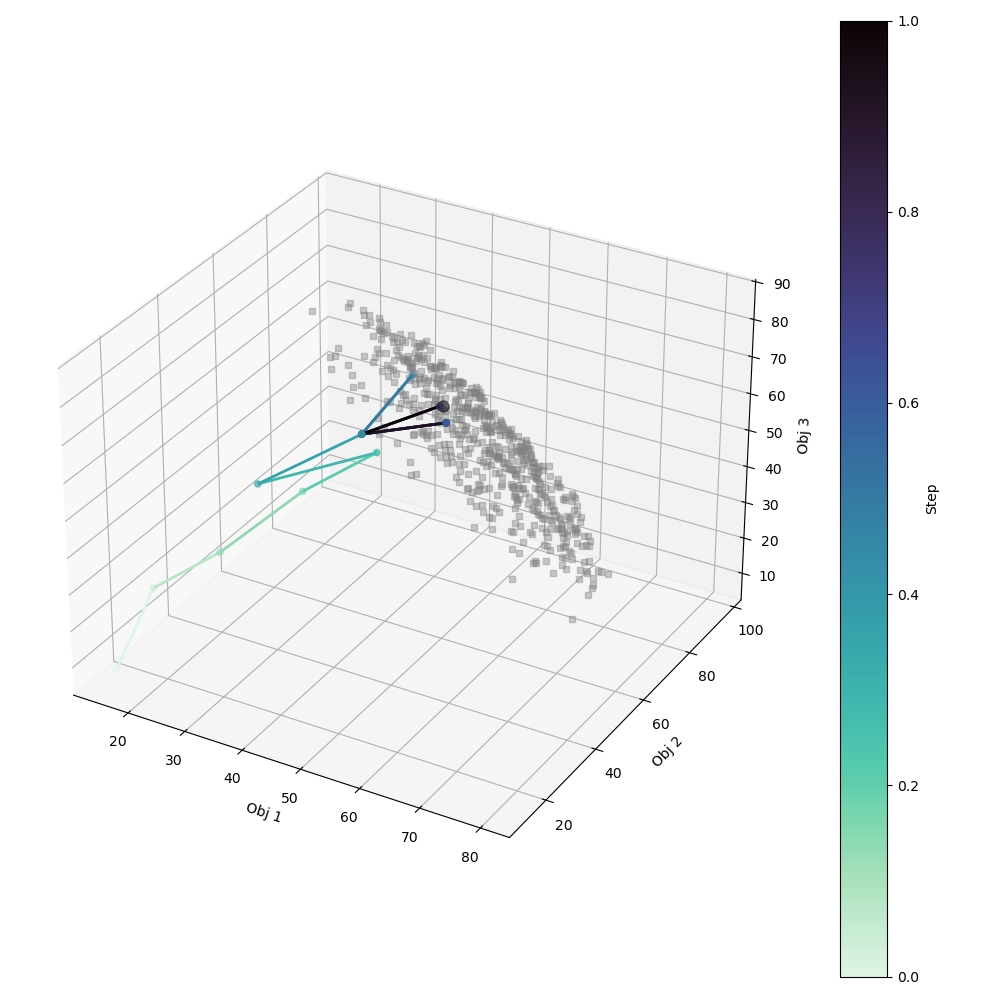

In [198]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
# colors = sns.color_palette("Set2", 6)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub4'

# for trial in range(2, 3):
trial = 6
for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
    print(file)
    data = pd.read_csv(file)

# add and remove  
card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
mask_add = card_op['operationType'] == 'add'
mask_remove = card_op['operationType'] == 'remove'
mask_obj = card_op.columns.str.contains('itemObj')
card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

obj_data = card_op.loc[:, mask_obj].values
obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

# find closest pareto front
pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
idx = np.argmin(dists)
closest_pf = pf_data[idx]
closest_dist = dists[idx]

print(obj_data_cumu[-1])
print(closest_pf)
print(closest_dist)

ax.plot(pf_data[:,0], pf_data[:,1], pf_data[:,2], 's', alpha=0.4, markersize=4, color='grey')
# ax.plot(obj_data_cumu[:,0], obj_data_cumu[:,1], obj_data_cumu[:,2], '-o', alpha=0.9, markersize=4, color=colors)

# plot path
x = obj_data_cumu[:, 0]
y = obj_data_cumu[:, 1]
z = obj_data_cumu[:, 2]
points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
t = np.linspace(0, 1, len(x) - 1)
lc = Line3DCollection(segments, cmap="mako_r", linewidth=1)
lc.set_array(t)
lc.set_linewidth(2)
ax.add_collection(lc)
sc = ax.scatter(x, y, z, c=np.linspace(0,1,len(x)), cmap="mako_r", s=20)
plt.colorbar(sc, ax=ax, label='Step')

ax.plot(closest_pf[0], closest_pf[1], closest_pf[2], '-o', alpha=0.5, markersize=8, color='black', markeredgecolor='black')

ax.set_xlabel('Obj 1')
ax.set_ylabel('Obj 2')
ax.set_zlabel('Obj 3')
plt.tight_layout()
plt.show()

/data/knapsack/card_game_log/pilot_sub4/TrialLog_25a3b5f3-85eb-46b5-99d8-cff0a293c88c_Trial10.csv
[88 80 93 91 85]
[90 86 97 95 87]
8.717797887081348


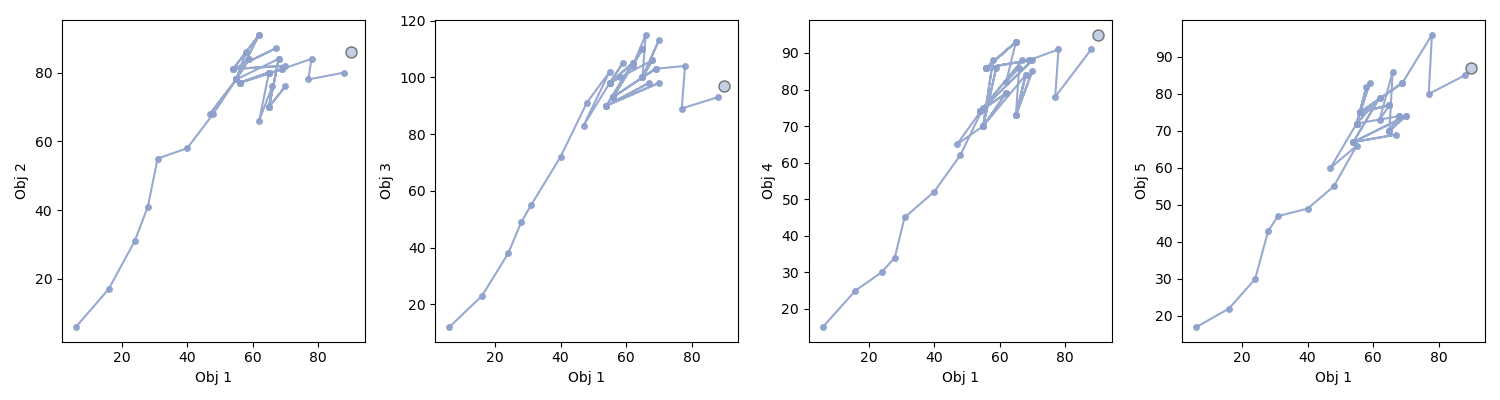

In [171]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = sns.color_palette("Set2", 3)
p_data_dir = '/data/knapsack/card_game_log/pilot_sub4'

for trial in range(10, 11):
    for file in Path(p_data_dir).glob(f'*Trial{trial}*'):
        print(file)
        data = pd.read_csv(file)

    # add and remove  
    card_op = data[data['operationType'].isin(['add', 'remove'])].copy()
    mask_add = card_op['operationType'] == 'add'
    mask_remove = card_op['operationType'] == 'remove'
    mask_obj = card_op.columns.str.contains('itemObj')
    card_op.loc[mask_remove, mask_obj] = -1 * card_op.loc[mask_remove, mask_obj]

    obj_data = card_op.loc[:, mask_obj].values
    obj_data_cumu = np.cumsum(obj_data, axis=0).astype(int)

    # find closest pareto front
    pf_data = pd.read_csv(f'eda_results/pf_trial{trial}.csv').to_numpy()
    dists = np.linalg.norm(pf_data - obj_data_cumu[-1], axis=1)
    idx = np.argmin(dists)
    closest_pf = pf_data[idx]
    closest_dist = dists[idx]

    print(obj_data_cumu[-1])
    print(closest_pf)
    print(closest_dist)

    for i in range(1, 5):
        # axes[i-1].plot(pf_data[:,0], pf_data[:,i], 's', alpha=0.2, markersize=4, color='grey')
        axes[i-1].plot(obj_data_cumu[:, 0], obj_data_cumu[:, i], '-o', alpha=0.9, markersize=4, color=colors[trial-8])
        axes[i-1].plot(closest_pf[0], closest_pf[i], '-o', alpha=0.5, markersize=8, color=colors[trial-8], markeredgecolor='black')
        axes[i-1].set_xlabel('Obj 1')
        axes[i-1].set_ylabel(f'Obj {i+1}')
plt.tight_layout()
plt.show()